<a href="https://colab.research.google.com/github/fikriwildann/customer-churn-prediction/blob/main/UAS_BENGKOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Customer Churn
# UAS BENGKEL KODING DATA SCIENCE
## Universitas Dian Nuswantoro

**Dataset:** Sales dan Marketing Dataset   
**Sumber:**  https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset  

### NAMA : Fikri Wildan Ariyananda
### NIM : A11.2023.15487

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# Sklearn - Evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

print("✅ Library berhasil diimpor")

✅ Library berhasil diimpor


# EDA

In [ ]:
# Load Dataset
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print(f"Ukuran dataset: {df.shape[0]:,} baris  ×  {df.shape[1]} kolom")
df.head()

Ukuran dataset: 15,000 baris  ×  30 kolom


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
# Informasi Dataset
print('=== INFORMASI DATASET ===')
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages

In [ ]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
df.describe().T

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.0,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.0,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.0,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.0,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.0,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.0,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.0,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.0,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.0,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.0,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


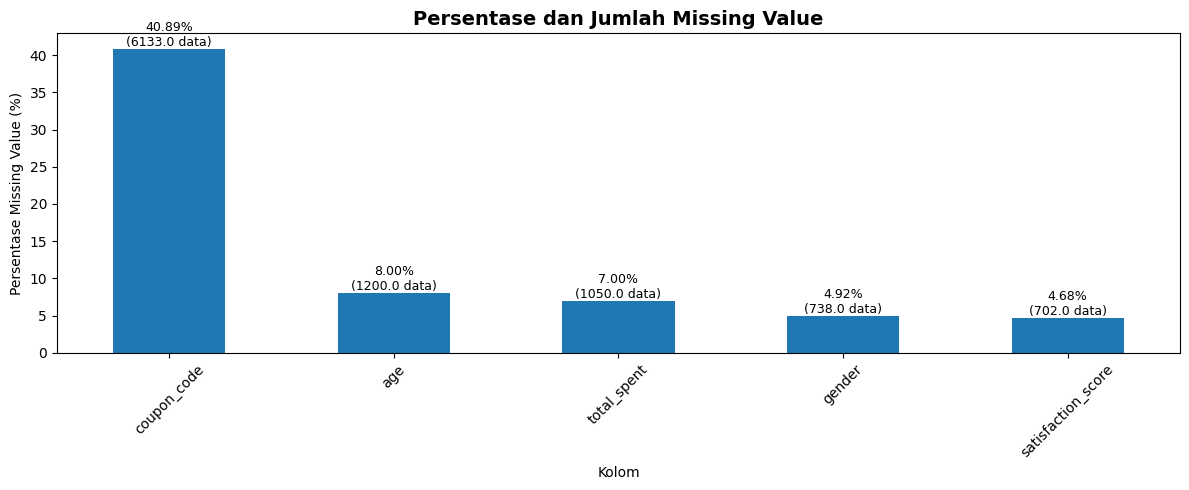

In [ ]:
# Menghitung persentase dan jumlah missing value
missing_percent = df.isnull().mean() * 100
missing_count = df.isnull().sum()

missing = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent
})


missing = missing[missing['Missing Count'] > 0]
missing = missing.sort_values(by='Missing Percent', ascending=False)

plt.figure(figsize=(12,5))

ax = missing['Missing Percent'].plot(
    kind='bar',
    color=sns.color_palette()[0]
)

for i, p in enumerate(ax.patches):
    ax.annotate(
        f'{p.get_height():.2f}%\n({missing.iloc[i]["Missing Count"]} data)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(
    'Persentase dan Jumlah Missing Value',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Kolom')
plt.ylabel('Persentase Missing Value (%)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

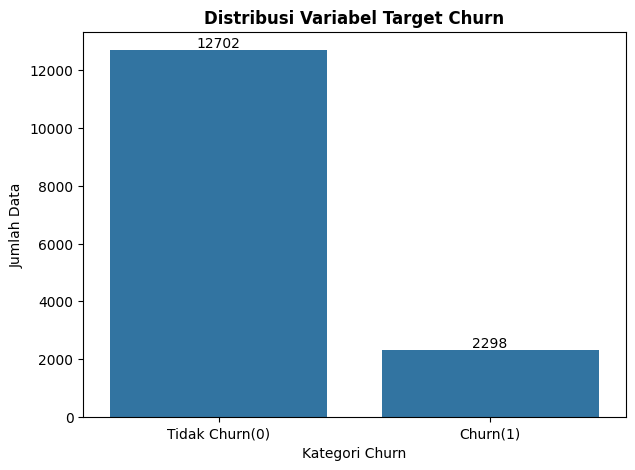

In [ ]:
# Distribusi Variabel Target (Churn)
plt.figure(figsize=(7,5))

ax = sns.countplot(x='churn', data=df)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title(
    'Distribusi Variabel Target Churn',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Kategori Churn')
plt.ylabel('Jumlah Data')

plt.xticks(
    ticks=[0, 1],
    labels=['Tidak Churn(0)', 'Churn(1)']
)

plt.show()

Kolom numerik (20): ['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


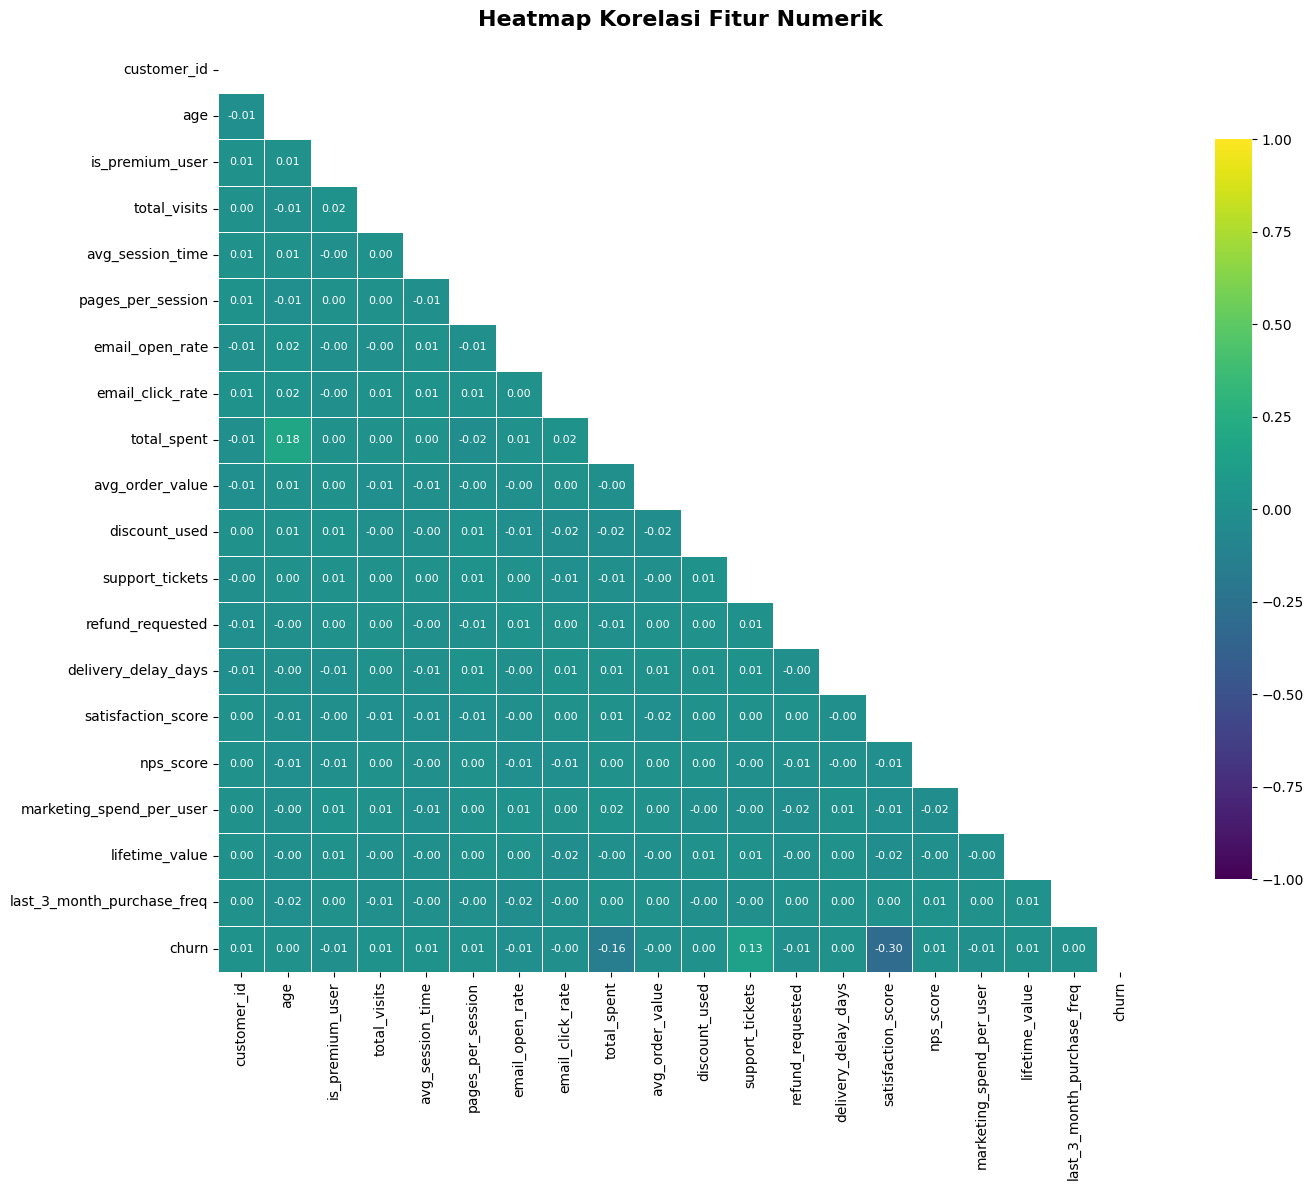


Top 10 fitur berkorelasi paling tinggi terhadap Churn:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
customer_id                 0.012208
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250


In [ ]:
# Heatmap Korelasi
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom numerik ({len(num_cols)}): {num_cols}')

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap='viridis', vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ─── Korelasi tertinggi terhadap target 'churn' ──────────────────────────────
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print('\nTop 10 fitur berkorelasi paling tinggi terhadap Churn:')
print(churn_corr.head(10).to_string())


# Direct Modeling

In [ ]:
# Menetapkan variabel target (y) yaitu kolom Churn, serta menggunakan seluruh kolom lain sebagai fitur prediktor
df_direct = df.copy()

# Encode kolom object agar bisa langsung dilatih (Label Encoding sederhana)
le = LabelEncoder()
obj_cols = df_direct.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal yang di-encode: {obj_cols}')

for col in obj_cols:
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))

# Definisikan X dan y
X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

# Isi missing value numerik secara minimal (median) agar model bisa berjalan
X_direct = X_direct.fillna(X_direct.median(numeric_only=True))

print(f'\nShape X: {X_direct.shape}')
print(f'Shape y: {y_direct.shape}')
print(f'Distribusi target:\n{y_direct.value_counts()}')

Kolom kategorikal yang di-encode: ['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

Shape X: (15000, 29)
Shape y: (15000,)
Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


In [ ]:
# Train-Test Split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

print(f'Data Latih : {X_train_d.shape[0]:,} sampel')
print(f'Data Uji   : {X_test_d.shape[0]:,} sampel')
print(f'Proporsi   : {len(X_train_d)/(len(X_train_d)+len(X_test_d)):.0%} train / {len(X_test_d)/(len(X_train_d)+len(X_test_d)):.0%} test')

Data Latih : 12,000 sampel
Data Uji   : 3,000 sampel
Proporsi   : 80% train / 20% test


In [ ]:
# Memilih 3 model
# Model 1 — Logistic Regression (Konvensional)
lr_direct = LogisticRegression(random_state=42, max_iter=1000)

# Model 2 — Random Forest (Ensemble Bagging)
rf_direct = RandomForestClassifier(random_state=42, n_estimators=100)

# Model 3 — LR + KNN + RF (Ensemble Voting)
lr_v  = LogisticRegression(random_state=42, max_iter=1000)
knn_v = KNeighborsClassifier()
rf_v  = RandomForestClassifier(random_state=42, n_estimators=50)
voting_direct = VotingClassifier(
    estimators=[('lr', lr_v), ('knn', knn_v), ('rf', rf_v)],
    voting='hard'
)

models_direct = {
    'Logistic Regression (Direct)': lr_direct,
    'Random Forest (Direct)': rf_direct,
    'Voting Classifier (Direct)': voting_direct,
}
print('Model siap dilatih!')

Model siap dilatih!



  Logistic Regression (Direct)
  Accuracy  : 0.8477
  Precision : 0.5108
  Recall    : 0.1543
  F1-Score  : 0.2371


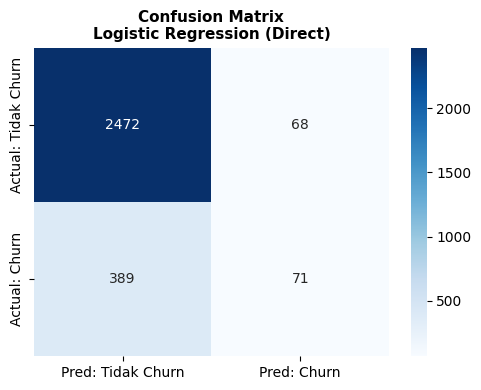


  Random Forest (Direct)
  Accuracy  : 0.8477
  Precision : 0.5053
  Recall    : 0.3130
  F1-Score  : 0.3866


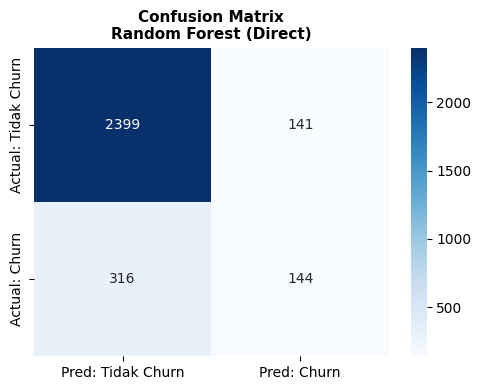


  Voting Classifier (Direct)
  Accuracy  : 0.8470
  Precision : 0.5048
  Recall    : 0.1152
  F1-Score  : 0.1876


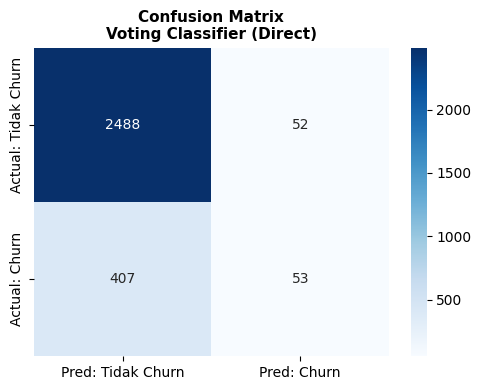

In [ ]:
# Melatih dan mengevaluasi model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Tidak Churn', 'Pred: Churn'],
                yticklabels=['Actual: Tidak Churn', 'Actual: Churn'])
    ax.set_title(f'Confusion Matrix\n{model_name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': round(acc, 4),
            'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1-Score': round(f1, 4)}


results_direct = []
for name, model in models_direct.items():
    res = evaluate_model(model, X_train_d, X_test_d, y_train_d, y_test_d, name)
    results_direct.append(res)

In [ ]:
# Rangkuman hasil direct modeling
df_result_direct = pd.DataFrame(results_direct).set_index('Model')
print('\nRangkuman Performa — Direct Modeling:')
print(df_result_direct.to_string())


Rangkuman Performa — Direct Modeling:
                              Accuracy  Precision  Recall  F1-Score
Model                                                              
Logistic Regression (Direct)    0.8477     0.5108  0.1543    0.2371
Random Forest (Direct)          0.8477     0.5053  0.3130    0.3866
Voting Classifier (Direct)      0.8470     0.5048  0.1152    0.1876


# Modeling Dengan Preprocessing

In [ ]:
# Muat Ulang Data Mentah
df_prep = df.copy()
print(f'Shape awal: {df_prep.shape}')

# Hapus duplikasi
n_dup = df_prep.duplicated().sum()
print(f'Jumlah duplikasi: {n_dup}')
df_prep.drop_duplicates(inplace=True)
print(f'Shape setelah hapus duplikasi: {df_prep.shape}')

Shape awal: (15000, 30)
Jumlah duplikasi: 0
Shape setelah hapus duplikasi: (15000, 30)


In [ ]:
# Penanganan Missing Value
print('Missing values sebelum imputasi:')
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

# Imputasi: median untuk numerik, modus untuk kategorikal
num_cols_prep = df_prep.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_prep = df_prep.select_dtypes(include='object').columns.tolist()

for col in num_cols_prep:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].median(), inplace=True)

for col in cat_cols_prep:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)

print(f'\nMissing values setelah imputasi: {df_prep.isnull().sum().sum()}')

Missing values sebelum imputasi:
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64

Missing values setelah imputasi: 0


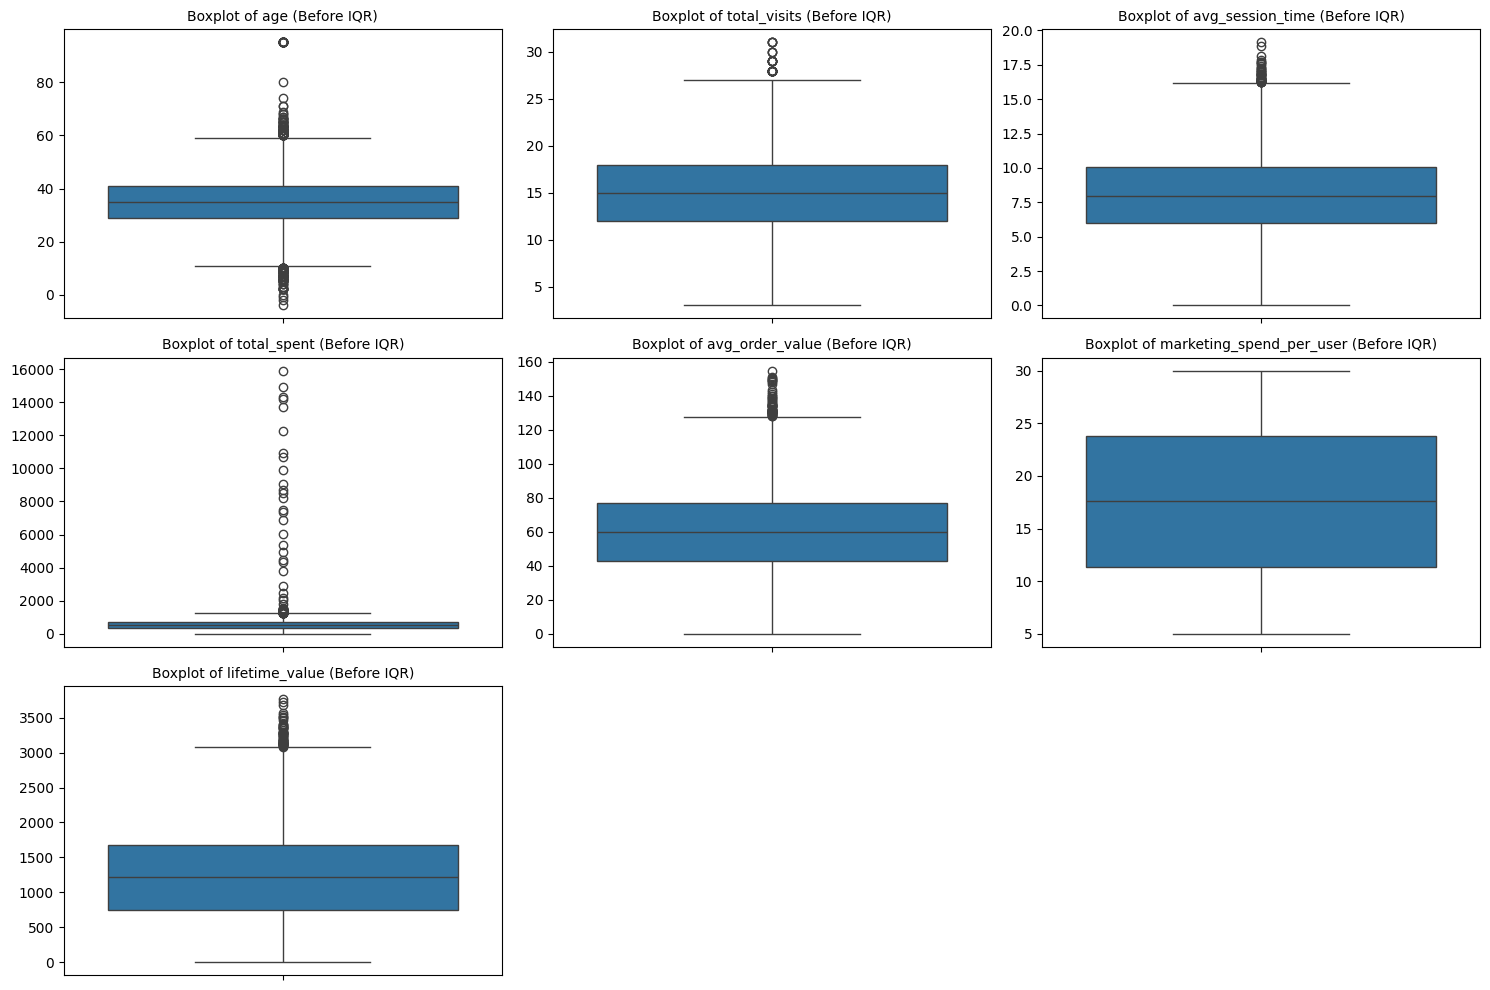

In [ ]:
num_outlier_cols = ['age', 'total_visits', 'avg_session_time', 'total_spent',
                    'avg_order_value', 'marketing_spend_per_user', 'lifetime_value']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_outlier_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_prep[col])
    plt.title(f'Boxplot of {col} (Before IQR)', fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Penanganan Outlier (IQR Method) pada fitur numerik kunci
num_outlier_cols = ['age', 'total_visits', 'avg_session_time', 'total_spent',
                    'avg_order_value', 'marketing_spend_per_user', 'lifetime_value']

def remove_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f'  {col}: dihapus {before - len(df):,} outlier, sisa {len(df):,} baris')
    return df

print(f'Shape sebelum: {df_prep.shape}')
for col in num_outlier_cols:
    df_prep = remove_outlier_iqr(df_prep, col)
print(f'Shape sesudah : {df_prep.shape}')

Shape sebelum: (15000, 30)
  age: dihapus 218 outlier, sisa 14,782 baris
  total_visits: dihapus 38 outlier, sisa 14,744 baris
  avg_session_time: dihapus 45 outlier, sisa 14,699 baris
  total_spent: dihapus 91 outlier, sisa 14,608 baris
  avg_order_value: dihapus 54 outlier, sisa 14,554 baris
  marketing_spend_per_user: dihapus 0 outlier, sisa 14,554 baris
  lifetime_value: dihapus 55 outlier, sisa 14,499 baris
Shape sesudah : (14499, 30)


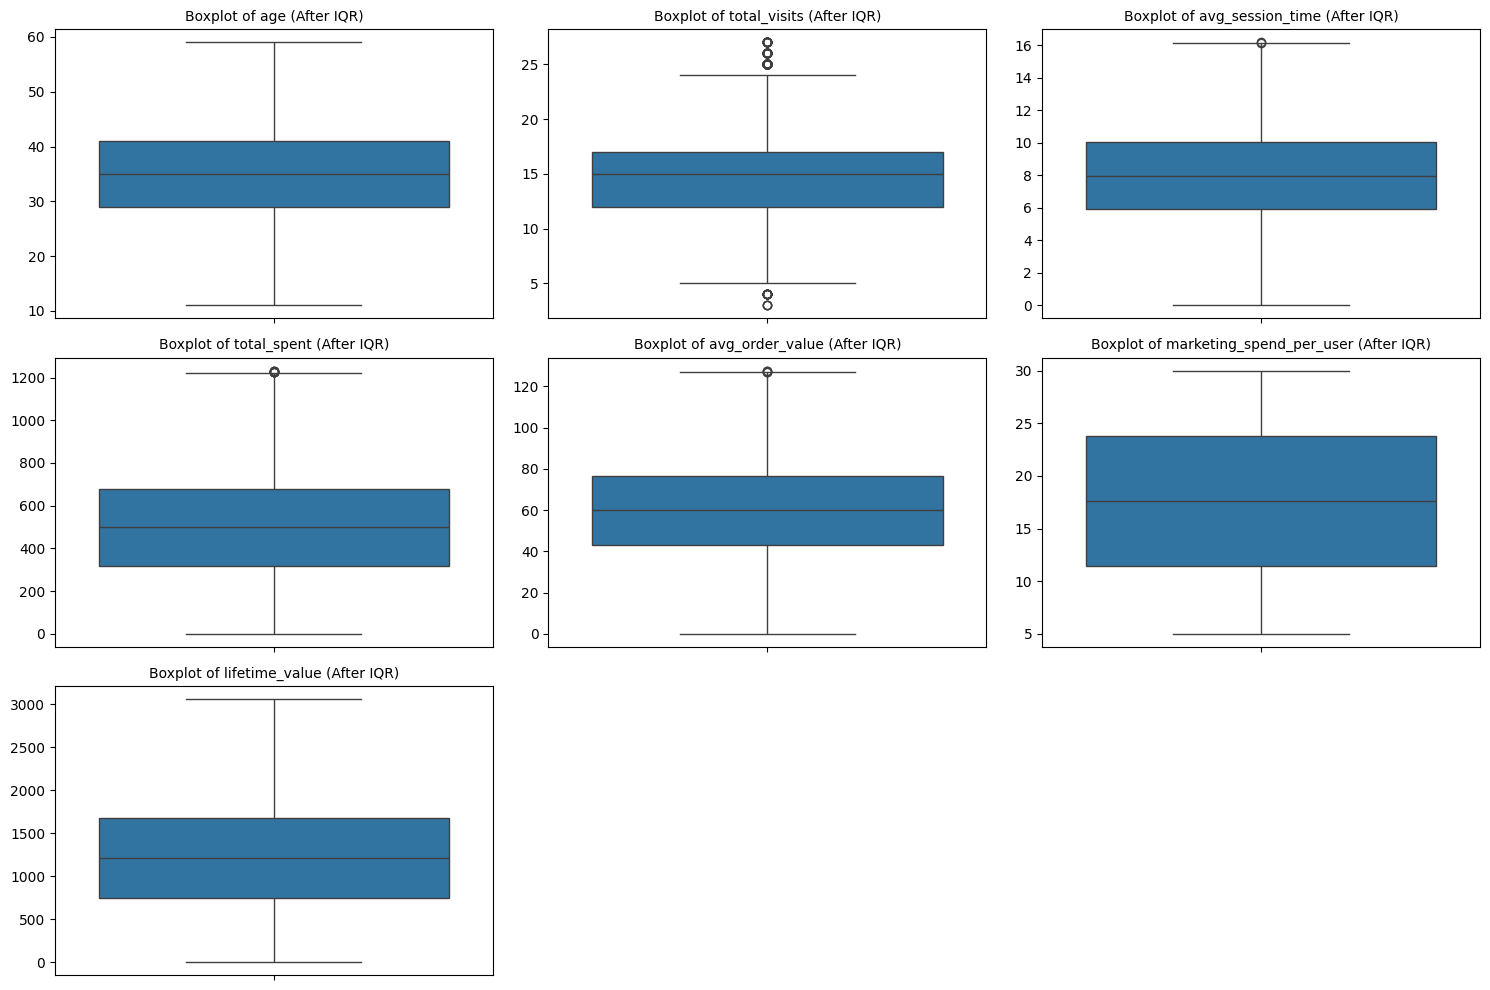

In [ ]:
num_outlier_cols = ['age', 'total_visits', 'avg_session_time', 'total_spent',
                    'avg_order_value', 'marketing_spend_per_user', 'lifetime_value']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_outlier_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_prep[col])
    plt.title(f'Boxplot of {col} (After IQR)', fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering — ekstrak info tanggal
df_prep['signup_date']        = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

ref_date = pd.Timestamp('2025-01-01')  # tanggal referensi
df_prep['days_since_signup']    = (ref_date - df_prep['signup_date']).dt.days
df_prep['days_since_purchase']  = (ref_date - df_prep['last_purchase_date']).dt.days
df_prep['tenure_days']          = (df_prep['last_purchase_date'] - df_prep['signup_date']).dt.days

# Hapus kolom tanggal asli dan kolom ID
drop_cols_prep = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_prep.drop(columns=drop_cols_prep, inplace=True, errors='ignore')

print(f'Fitur baru ditambahkan: days_since_signup, days_since_purchase, tenure_days')
print(f'Shape setelah feature engineering: {df_prep.shape}')

Fitur baru ditambahkan: days_since_signup, days_since_purchase, tenure_days
Shape setelah feature engineering: (14499, 29)


In [ ]:
# Encoding Fitur Kategorikal (One-Hot Encoding)
cat_to_encode = df_prep.select_dtypes(include='object').columns.tolist()
print(f'Kolom yang di-encode: {cat_to_encode}')

df_prep = pd.get_dummies(df_prep, columns=cat_to_encode, drop_first=True)

print(f'Shape setelah One-Hot Encoding: {df_prep.shape}')
df_prep.head(3)

Kolom yang di-encode: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
Shape setelah One-Hot Encoding: (14499, 45)


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,acquisition_channel_Google Ads,acquisition_channel_Organic,acquisition_channel_Referral,device_type_Mobile,device_type_Tablet,subscription_type_Monthly,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,...,False,False,False,False,True,False,False,False,False,True
1,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,...,False,True,False,False,False,True,False,False,False,False
2,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
# Train–Test Split (setelah Preprocessing)
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

# Proposi split SAMA dengan direct modeling (80:20)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep,test_size=0.2, random_state=42, stratify=y_prep
)

print(f'Shape X: {X_prep.shape}')
print(f'Data Latih : {X_train_p.shape[0]:,} sampel')
print(f'Data Uji   : {X_test_p.shape[0]:,} sampel')

Shape X: (14499, 44)
Data Latih : 11,599 sampel
Data Uji   : 2,900 sampel


In [ ]:
# Scaling
scaler = StandardScaler()

# Fit HANYA pada data latih, transform keduanya
X_train_p_sc = scaler.fit_transform(X_train_p)
X_test_p_sc  = scaler.transform(X_test_p)

print(f'Scaling selesai.')
print(f'  Mean train (feature 0): {X_train_p_sc[:, 0].mean():.4f}  (harus ~0)')
print(f'  Std  train (feature 0): {X_train_p_sc[:, 0].std():.4f}   (harus ~1)')

Scaling selesai.
  Mean train (feature 0): -0.0000  (harus ~0)
  Std  train (feature 0): 1.0000   (harus ~1)


In [ ]:
# Penanganan Class Imbalance dengan SMOTE
print('Distribusi kelas sebelum SMOTE:')
print(pd.Series(y_train_p).value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p_sc, y_train_p)

print('\nDistribusi kelas setelah SMOTE:')
print(pd.Series(y_train_sm).value_counts())
print(f'\nJumlah data train: {len(X_train_sm):,} sampel')

Distribusi kelas sebelum SMOTE:
churn
0    9812
1    1787
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
churn
0    9812
1    9812
Name: count, dtype: int64

Jumlah data train: 19,624 sampel



  Logistic Regression (Preprocessing)
  Accuracy  : 0.7703
  Precision : 0.3834
  Recall    : 0.8054
  F1-Score  : 0.5195


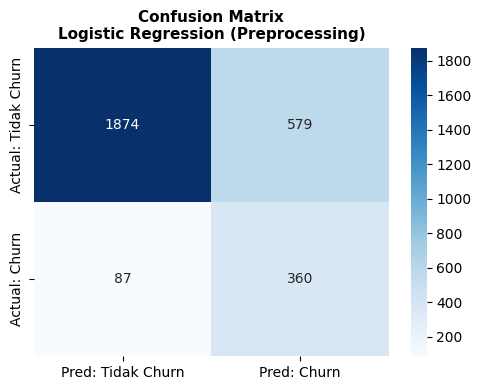


  Random Forest (Preprocessing)
  Accuracy  : 0.8476
  Precision : 0.5050
  Recall    : 0.5615
  F1-Score  : 0.5318


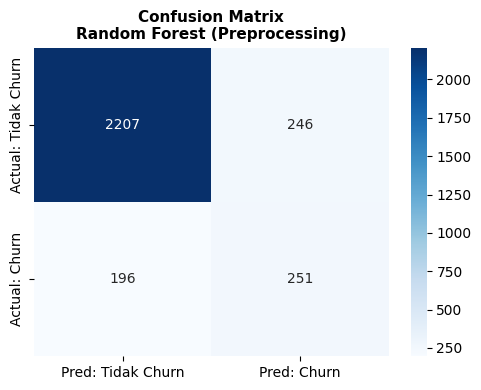


  Voting Classifier (Preprocessing)
  Accuracy  : 0.7990
  Precision : 0.4137
  Recall    : 0.7293
  F1-Score  : 0.5279


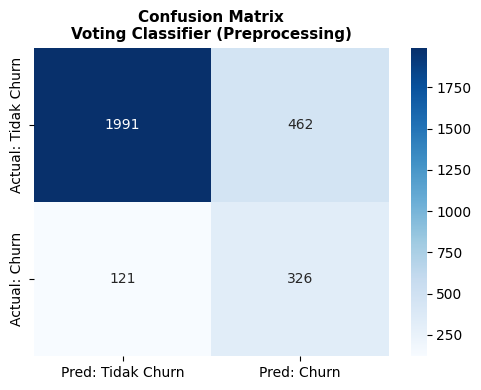

In [ ]:
# Model 1 — Logistic Regression (Konvensional)
lr_prep = LogisticRegression(random_state=42, max_iter=1000)

# Model 2 — Random Forest (Ensemble Bagging)
rf_prep = RandomForestClassifier(random_state=42, n_estimators=100)

# Model 3 — LR + KNN + RF (Ensemble Voting)
lr_vp  = LogisticRegression(random_state=42, max_iter=1000)
knn_vp = KNeighborsClassifier()
rf_vp  = RandomForestClassifier(random_state=42, n_estimators=50)
voting_prep = VotingClassifier(
    estimators=[('lr', lr_vp), ('knn', knn_vp), ('rf', rf_vp)],
    voting='hard'
)

models_prep = {
    'Logistic Regression (Preprocessing)': lr_prep,
    'Random Forest (Preprocessing)': rf_prep,
    'Voting Classifier (Preprocessing)': voting_prep,
}

results_prep = []
for name, model in models_prep.items():
    res = evaluate_model(model, X_train_sm, X_test_p_sc, y_train_sm, y_test_p, name)
    results_prep.append(res)


In [ ]:
# Rangkuman hasil Modeling dengan Preprocessing
df_prep_res = pd.DataFrame(results_prep).set_index('Model')
print('\nRangkuman Performa — Modeling dengan Preprocessing:')
print(df_prep_res.to_string())


Rangkuman Performa — Modeling dengan Preprocessing:
                                     Accuracy  Precision  Recall  F1-Score
Model                                                                     
Logistic Regression (Preprocessing)    0.7703     0.3834  0.8054    0.5195
Random Forest (Preprocessing)          0.8476     0.5050  0.5615    0.5318
Voting Classifier (Preprocessing)      0.7990     0.4137  0.7293    0.5279


# Hyperparameter Tuning dan Feature Selection

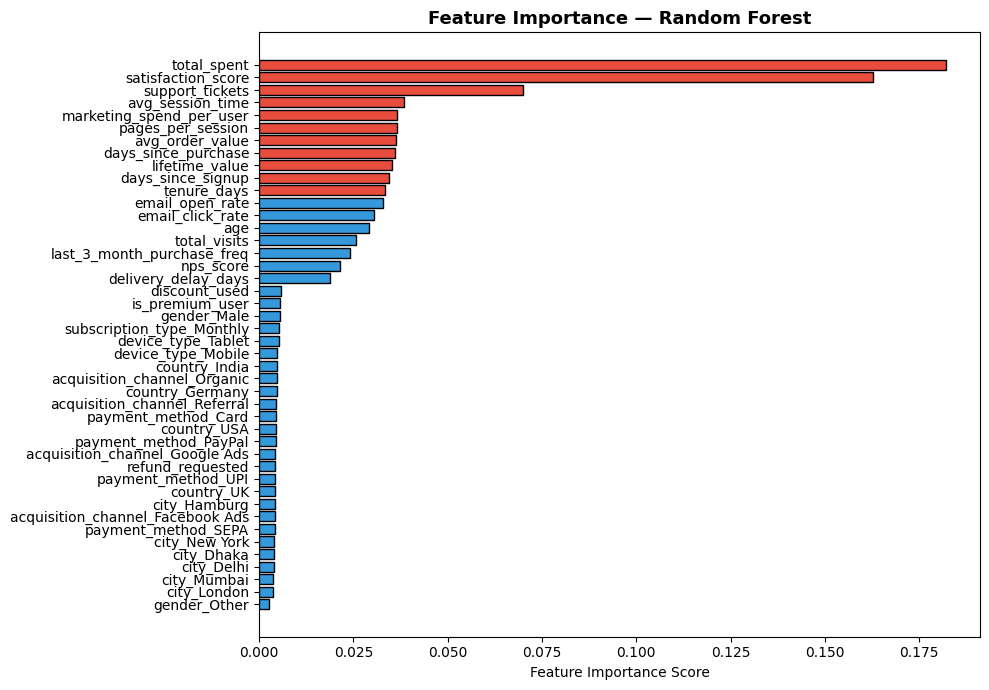

Top 10 Fitur Paling Berpengaruh:
total_spent                 0.182002
satisfaction_score          0.162687
support_tickets             0.069923
avg_session_time            0.038360
marketing_spend_per_user    0.036678
pages_per_session           0.036443
avg_order_value             0.036236
days_since_purchase         0.035909
lifetime_value              0.035106
days_since_signup           0.034421


In [ ]:
# Mengunakan Random Forest untuk feature importance
rf_fi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fi.fit(X_train_p, y_train_p)

fi = pd.Series(rf_fi.feature_importances_, index=X_prep.columns)
fi_sorted = fi.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v >= fi_sorted.quantile(0.75) else '#3498db' for v in fi_sorted.values]
bars = plt.barh(fi_sorted.index[::-1], fi_sorted.values[::-1], color=colors[::-1], edgecolor='black')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 Fitur Paling Berpengaruh:')
print(fi_sorted.head(10).to_string())

In [ ]:
# Memilih top 15 fitur
top_features = fi_sorted.head(15).index.tolist()
print('Fitur terpilih:', top_features)

X_train_sm_df = pd.DataFrame(X_train_sm, columns=X_prep.columns)
X_test_p_df   = pd.DataFrame(X_test_p_sc, columns=X_prep.columns)

X_train_fs = X_train_sm_df[top_features]
X_test_fs = X_test_p_df[top_features]

# Scaling ulang
scaler_fs = StandardScaler()
X_train_fs_scaled = scaler_fs.fit_transform(X_train_fs)
X_test_fs_scaled  = scaler_fs.transform(X_test_fs)

print(f'Shape fitur terpilih: {X_train_fs.shape}')

Fitur terpilih: ['total_spent', 'satisfaction_score', 'support_tickets', 'avg_session_time', 'marketing_spend_per_user', 'pages_per_session', 'avg_order_value', 'days_since_purchase', 'lifetime_value', 'days_since_signup', 'tenure_days', 'email_open_rate', 'email_click_rate', 'age', 'total_visits']
Shape fitur terpilih: (19624, 15)


In [ ]:
# Hyperparameter Tuning — Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500]
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_fs_scaled, y_train_sm)

print('Best Params LR :', gs_lr.best_params_)
print('Best CV Score  :', round(gs_lr.best_score_, 4))

Best Params LR : {'C': 0.01, 'max_iter': 200, 'solver': 'liblinear'}
Best CV Score  : 0.7773


In [ ]:
# Hyperparameter Tuning — Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, n_iter=10, cv=5, scoring='f1',
    n_jobs=-1, random_state=42, verbose=0
)
gs_rf.fit(X_train_fs, y_train_sm)

print('Best Params RF :', gs_rf.best_params_)
print('Best CV Score  :', round(gs_rf.best_score_, 4))


Best Params RF : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV Score  : 0.9044


In [ ]:
# Hyperparameter Tuning — Voting Classifier
lr_best  = gs_lr.best_estimator_
rf_best  = gs_rf.best_estimator_
knn_tune = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

voting_tuned = VotingClassifier(
    estimators=[('lr', lr_best), ('knn', knn_tune), ('rf', rf_best)],
    voting='hard'
)

print('Voting Classifier dengan komponen yang telah dituning siap dilatih.')

Voting Classifier dengan komponen yang telah dituning siap dilatih.



  Logistic Regression (Tuned)
  Accuracy  : 0.7724
  Precision : 0.3861
  Recall    : 0.8076
  F1-Score  : 0.5224


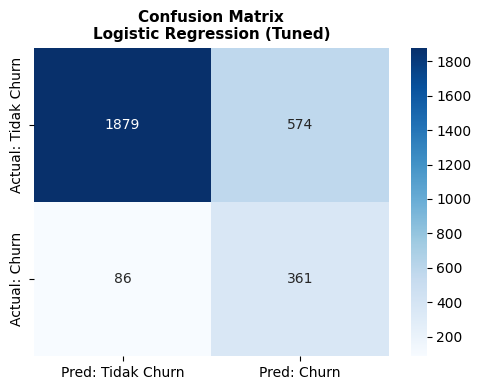


  Random Forest (Tuned)
  Accuracy  : 0.8538
  Precision : 0.5195
  Recall    : 0.6846
  F1-Score  : 0.5907


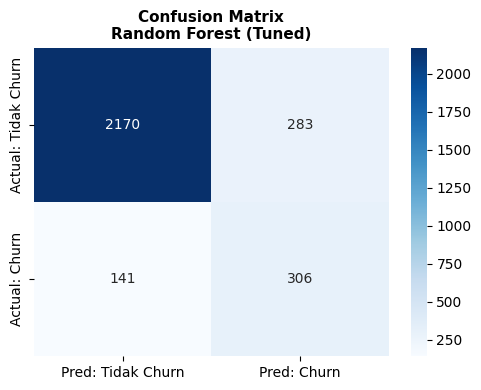


  Voting Classifier (Tuned)
  Accuracy  : 0.8190
  Precision : 0.4517
  Recall    : 0.8166
  F1-Score  : 0.5817


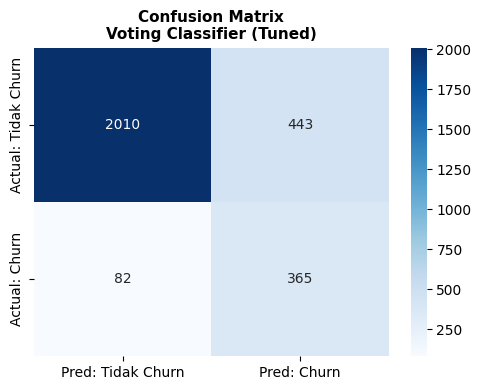

In [ ]:
# Evaluasi Model setelah Tuning
lr_final     = gs_lr.best_estimator_
rf_final     = gs_rf.best_estimator_
voting_final = voting_tuned

models_tuned = {
    'Logistic Regression (Tuned)': (lr_final, X_train_fs_scaled, X_test_fs_scaled),
    'Random Forest (Tuned)': (rf_final, X_train_fs, X_test_fs),
    'Voting Classifier (Tuned)': (voting_final, X_train_fs_scaled, X_test_fs_scaled),
}

results_tuned = []
for name, (model, X_tr, X_te) in models_tuned.items():
    res = evaluate_model(model, X_tr, X_te, y_train_sm, y_test_p, name)
    results_tuned.append(res)

In [ ]:
# Rangkuman Hasil Hyperparameter Tuning
df_tuned_res = pd.DataFrame(results_tuned).set_index('Model')
print('\nRangkuman Performa — Hyperparameter Tuning:')
print(df_tuned_res.to_string())


Rangkuman Performa — Hyperparameter Tuning:
                             Accuracy  Precision  Recall  F1-Score
Model                                                             
Logistic Regression (Tuned)    0.7724     0.3861  0.8076    0.5224
Random Forest (Tuned)          0.8538     0.5195  0.6846    0.5907
Voting Classifier (Tuned)      0.8190     0.4517  0.8166    0.5817


=== PERBANDINGAN SELURUH 9 MODEL ===
                                     Accuracy  Precision  Recall  F1-Score
Model                                                                     
Logistic Regression (Direct)           0.8477     0.5108  0.1543    0.2371
Random Forest (Direct)                 0.8477     0.5053  0.3130    0.3866
Voting Classifier (Direct)             0.8470     0.5048  0.1152    0.1876
Logistic Regression (Preprocessing)    0.7703     0.3834  0.8054    0.5195
Random Forest (Preprocessing)          0.8476     0.5050  0.5615    0.5318
Voting Classifier (Preprocessing)      0.7990     0.4137  0.7293    0.5279
Logistic Regression (Tuned)            0.7724     0.3861  0.8076    0.5224
Random Forest (Tuned)                  0.8538     0.5195  0.6846    0.5907
Voting Classifier (Tuned)              0.8190     0.4517  0.8166    0.5817


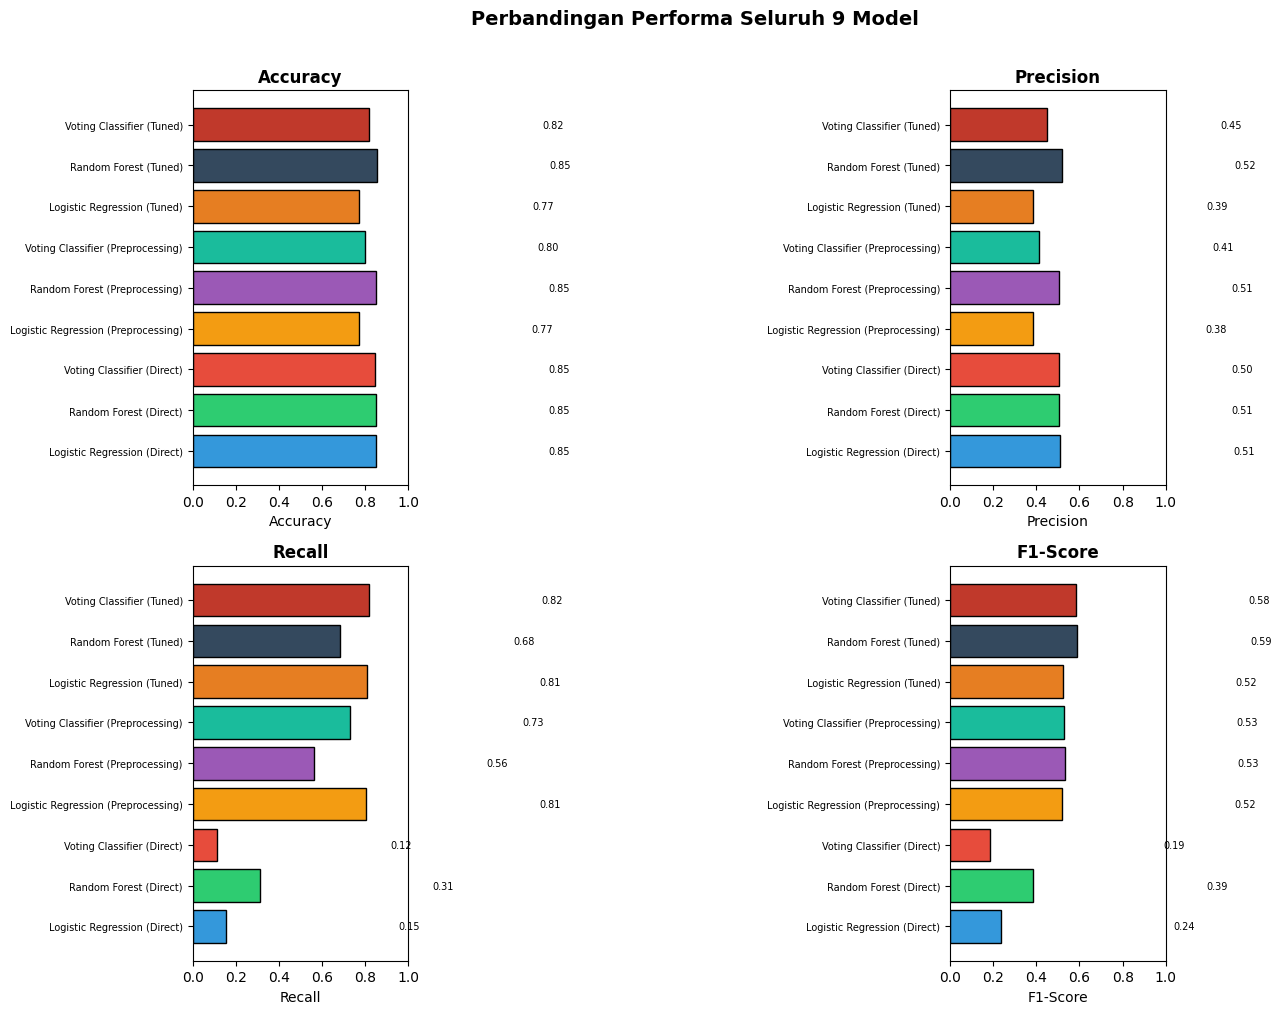

In [ ]:
# Perbandingan Seluruh Model & Identifikasi Model Terbaik
all_results = results_direct + results_prep + results_tuned
df_all = pd.DataFrame(all_results).set_index('Model')

print('=== PERBANDINGAN SELURUH 9 MODEL ===')
print(df_all.to_string())

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6',
              '#1abc9c', '#e67e22', '#34495e', '#c0392b']

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.barh(df_all.index, df_all[metric], color=colors_bar, edgecolor='black')
    ax.set_xlabel(metric)
    ax.set_title(metric, fontsize=12, fontweight='bold')

    ax.set_xlim(0, 1)
    for bar, val in zip(bars, df_all[metric]):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Perbandingan Performa Seluruh 9 Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Identifikasi model terbaik berdasarkan F1-Score
best_model_name = df_all['F1-Score'].idxmax()
best_row = df_all.loc[best_model_name]

print(f'Model Terbaik : {best_model_name}')
print(f'  Accuracy  : {best_row["Accuracy"]}')
print(f'  Precision : {best_row["Precision"]}')
print(f'  Recall    : {best_row["Recall"]}')
print(f'  F1-Score  : {best_row["F1-Score"]}')

Model Terbaik : Random Forest (Tuned)
  Accuracy  : 0.8538
  Precision : 0.5195
  Recall    : 0.6846
  F1-Score  : 0.5907


# Deployment

In [ ]:
# Menyimpan Model Terbaik & Parameter Pendukung
import joblib
import os

os.makedirs('deployment', exist_ok=True)

if best_model_name != 'Random Forest (Tuned)':
    print(f"PERHATIAN: model terbaik saat ini adalah '{best_model_name}', namun kode "
          f"di bawah disiapkan khusus untuk skema scaling Random Forest (Tuned). "
          f"Sesuaikan kembali skema scaling jika model terbaik berubah saat notebook dijalankan ulang.")

best_model = rf_final  # Random Forest (Tuned) -> model dengan F1-Score tertinggi
feature_indices = [list(X_prep.columns).index(f) for f in top_features]
scaler_params = {
    feat: {'mean': float(scaler.mean_[idx]), 'std': float(scaler.scale_[idx])}
    for feat, idx in zip(top_features, feature_indices)
}

joblib.dump(best_model, 'deployment/model_churn_rf.joblib')
joblib.dump(scaler_params, 'deployment/scaler_params.joblib')
joblib.dump(top_features, 'deployment/top_features.joblib')

print(f'Model terbaik : {best_model_name}')
print(f'F1-Score      : {best_row["F1-Score"]}')
print(f'Jumlah fitur  : {len(top_features)}')
print('\nArtefak tersimpan di folder deployment/:')
for fname in sorted(os.listdir('deployment')):
    print(' -', fname)

Model terbaik : Random Forest (Tuned)
F1-Score      : 0.5907
Jumlah fitur  : 15

Artefak tersimpan di folder deployment/:
 - model_churn_rf.joblib
 - scaler_params.joblib
 - top_features.joblib


# Kesimpulan


Berdasarkan hasil eksperimen yang telah dilakukan, preprocessing terbukti menjadi faktor penentu yang jauh lebih besar dibandingkan pemilihan algoritma itu sendiri. Hal ini terlihat jelas dari perbandingan antara skenario direct modeling dan skenario dengan preprocessing meskipun algoritmanya sama, performa model meningkat cukup drastis setelah data dibersihkan dan ditangani dengan benar.


Masalah class imbalance pada dataset ini (84,68% tidak churn vs 15,32% churn) juga tidak bisa diabaikan begitu saja. Terbukti di skenario direct modeling, accuracy memang tinggi tapi recall-nya sangat buruk, artinya model hampir tidak mampu mendeteksi pelanggan yang benar-benar churn. Setelah SMOTE diterapkan khusus pada data training, kemampuan model dalam mengenali kelas minoritas meningkat signifikan tanpa harus "memanipulasi" data uji.


Dari keseluruhan 9 model yang diuji, Random Forest (Tuned) menjadi model terbaik dengan F1-Score 0.5907, Accuracy 0.8538, Recall 0.6846, dan Precision 0.5195. Model ini dipilih berdasarkan F1-Score karena pada kasus imbalance, F1-Score lebih mencerminkan performa model yang sesungguhnya dibandingkan accuracy semata.

Nilai F1-Score sebesar 0.59 ini bukan angka yang sempurna, dan memang tidak harus sempurna. Dataset churn pada dunia nyata memang kompleks dan tidak selalu bisa diprediksi dengan presisi tinggi. Yang terpenting, model ini sudah cukup mampu membantu mengidentifikasi pelanggan berisiko churn sehingga bisa dijadikan dasar pengambilan keputusan bisnis, bukan sekadar alat prediksi otomatis.